# Forecasting climate data using Physics Informed Long Short-Term Memory networks (PI-LSTM)



This code implements the PINT LSTM ([Code](https://github.com/KV-Park/PINT/blob/main/PINT%5BTraining%5D.ipynb) | [Paper](https://arxiv.org/pdf/2502.04018)) to forecast on the Kaggle "Daily Climate time series data" dataset.

Dataset:
- Download dataset from [here](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data) and store in data/ folder in this repository

In [ ]:
import os
import random
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch  
import torch.nn as nn  
import torch.optim as optim
from matplotlib.dates import MonthLocator, DayLocator, DateFormatter
from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Key parameters:
SEED_VALUE = 2026

# Preprocessing
SEQ_LENGTH = 20  # Number of past time steps to look at 
PRED_LENGTH = 15  # Number of time steps to predict

# Model set up
input_size=1
output_size = PRED_LENGTH
hidden_size=64
num_layers=1
dropout=0
NUM_EPOCHS=50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def set_seed(seed):
    random.seed(seed)  # Python
    np.random.seed(seed)  # NumPy
    torch.manual_seed(seed)  # PyTorch CPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False 
set_seed(SEED_VALUE)

## Import data

In [33]:
files = ["DailyDelhiClimateTrain.csv", "DailyDelhiClimateTest.csv"]

data = []
for file in files:
    df = pd.read_csv(os.path.join("data/", file))
    df["datetimes"] = [datetime.strptime(d,'%Y-%m-%d').date() for d in df["date"].values]
    if "Train" in file:
        # print("End of \"Train\" data before:\n", df.tail())  # Shows 2017-01-01 at end
        df = df[:-1]  # Remove last row of training data because of duplcate in test
        # print("End of \"Train\" data after dropping last row:\n", df.tail())  # Shows 2017-01-01 at end
    # else:
        # print("Start of \"Test\" data:\n", df.head())  # Shows 2017-01-01 at start
    data.append(df)

all_data_df = pd.concat(data, ignore_index=True)

## Pre-process data

In [34]:
# split training:val:test as 80:15:15
train_df = all_data_df.loc[:int(len(all_data_df)*0.7)].copy()
val_df = all_data_df.loc[int(len(all_data_df)*0.7):int(len(all_data_df)*0.85)].copy()
test_df = all_data_df.loc[int(len(all_data_df)*0.85):].copy()

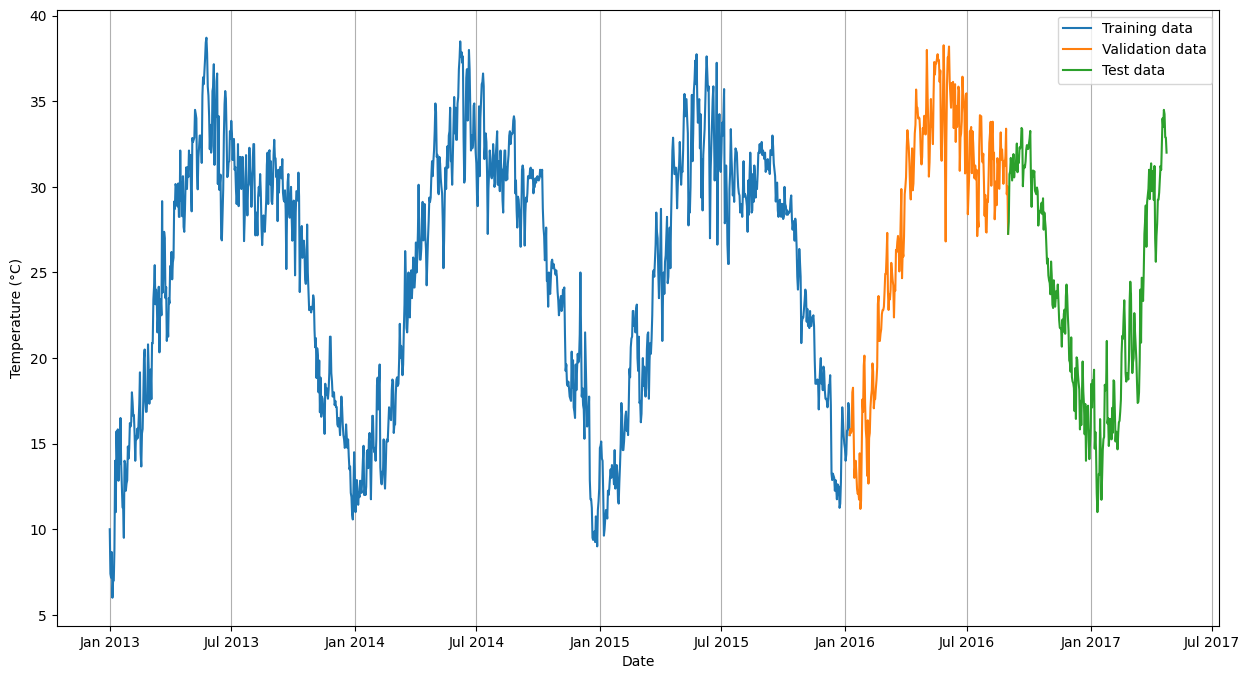

In [35]:
# Plot temperature variation across training dataset
fig = plt.figure(figsize=(15,8))
plt.plot(train_df["datetimes"], train_df["meantemp"], label="Training data")
plt.plot(val_df["datetimes"], val_df["meantemp"], label="Validation data")
plt.plot(test_df["datetimes"], test_df["meantemp"], label="Test data")
ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator(interval=6))
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
ax.grid(visible=True, axis="x")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

In [36]:
# Normalise inputs to be between 0 and 1
scaler = MinMaxScaler()

train_df["meantemp_norm"] = scaler.fit_transform(train_df[["meantemp"]])
val_df["meantemp_norm"] = scaler.fit_transform(val_df[["meantemp"]])
test_df["meantemp_norm"] = scaler.fit_transform(test_df[["meantemp"]])

# Convert to numpy array for sequence creation
meantemp_train = train_df["meantemp_norm"].values
meantemp_val = val_df["meantemp_norm"].values
meantemp_test = test_df["meantemp_norm"].values

In [37]:
# Create sequences and labels
def create_sequences(data, seq_length, pred_length):
  xs, ys = [], []
  for i in range(len(data) - seq_length - pred_length + 1):
    xs.append(data[i:i+seq_length]) # Sequence of length `seq_length`
    ys.append(data[i+seq_length:i+seq_length+pred_length]) # Next sequence of length `pred_length`
  return np.array(xs), np.array(ys)

# Create sequences
X_train, y_train = create_sequences(meantemp_train, SEQ_LENGTH, PRED_LENGTH)
X_val, y_val = create_sequences(meantemp_val, SEQ_LENGTH, PRED_LENGTH)
X_test, y_test = create_sequences(meantemp_test, SEQ_LENGTH, PRED_LENGTH)

# Convert arrays to PyTorch tensors
X_train = torch.Tensor(X_train).unsqueeze(-1) # Shape: (batch, seq, input_size)
y_train = torch.Tensor(y_train)
X_val = torch.Tensor(X_val).unsqueeze(-1) # Shape: (batch, seq, input_size)
y_val = torch.Tensor(y_val)
X_test = torch.Tensor(X_test).unsqueeze(-1)
y_test = torch.Tensor(y_test)

In [39]:
len_data = len(X_train) + len(X_val) + len(X_test)
print(f"Train:val:test ratio: {len(X_train)}:\
{len(X_val)}:{len(X_test)}")
print(f"Train:val:test ratio: \
{len(X_train)/len_data*100:.2f}%:\
{len(X_val)/len_data*100:.2f}%:\
{len(X_test)/len_data*100:.2f}%")

Train:val:test ratio: 1069:203:203
Train:val:test ratio: 72.47%:13.76%:13.76%


## Define and train models

* input_size = 1 because we have one feature (value per time step).
* hidden_size is the size of the hidden state.
* batch_first=True ensures input is in the format (batch, seq_len, input_size).

### Baseline model

In [40]:
class LSTM(nn.Module):
    """LSTM"""
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

### PINT
Sources: [Code](https://github.com/KV-Park/PINT/blob/main/PINT%5BTraining%5D.ipynb) | [Paper](https://arxiv.org/pdf/2502.04018)

In [41]:
class PhysicsInformedLSTM(nn.Module):
    """Physics-Informed LSTM"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, omega_init=2*np.pi/365):
        super(PhysicsInformedLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.omega = nn.Parameter(torch.tensor(omega_init))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

    def physics_loss(self, y_pred, t):
        dt = t[1] - t[0]
        y_dot = (y_pred[:, 1:] - y_pred[:, :-1]) / dt
        y_double_dot = (y_dot[:, 1:] - y_dot[:, :-1]) / dt
        y_mid = y_pred[:, 1:-1]
        physics_residual = y_double_dot + (self.omega ** 2) * y_mid
        
        sequence_length = y_pred.size(1)
        return torch.mean(physics_residual ** 2) / sequence_length**2

### Train models

In [42]:
# Initialise models
models = {
    "LSTM": LSTM(input_size, hidden_size, num_layers, output_size),
    "PI-LSTM": PhysicsInformedLSTM(input_size, hidden_size, num_layers, output_size)
}

In [43]:
def plot_loss(training_loss, val_loss, num_epochs):
    """Plot the loss at each epoch to visualize model convergence"""
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, num_epochs + 1), training_loss, label='Training Loss', color='purple')
    plt.plot(range(1, num_epochs + 1), val_loss, label='Validation Loss', color='cyan')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def train_and_tune_models(models, X_train, y_train, X_val, y_val,
                          num_epochs=1000, lr=0.001, physics_loss_weight=0.001,
                          omega=2 * np.pi / 365):
    trained_models = {}

    for name, model in models.items():
        # Check if the model is physics-informed
        is_physics_informed = hasattr(model, "physics_loss")
        if is_physics_informed:
            print(f"Training Physics-Informed Model: {name}")
            # Set omega for the physics-informed model
            if hasattr(model, "omega"):
                model.omega = nn.Parameter(torch.tensor(omega, dtype=torch.float32, device=model.omega.device))
            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=0.01)
            
            total_losses = []
            val_total_losses = []
            
            for epoch in range(num_epochs):
                model.train()
                optimizer.zero_grad()

                # Forward pass
                output = model(X_train)
                data_loss = criterion(output.squeeze(), y_train)  # Compute loss

                # Physics loss
                physics_loss = model.physics_loss(
                    output,
                    torch.linspace(0, 1, steps=output.size(1), device=output.device)
                )
                total_loss = data_loss + physics_loss_weight * physics_loss

                # Backward pass and optimization
                total_loss.backward()
                optimizer.step()

                # Logging
                total_losses.append(total_loss.item())
                if (epoch + 1) % 10 == 0:
                    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss.item():.4f}")

                # Validation
                model.eval()
                val_preds = model(X_val)
                val_data_loss = criterion(val_preds.squeeze(), y_val)
                val_physics_loss = model.physics_loss(
                    val_preds,
                    torch.linspace(0, 1, steps=output.size(1), device=output.device)
                )
                val_total_loss = val_data_loss + physics_loss_weight * val_physics_loss
                val_total_losses.append(val_total_loss.item())

            #Store and plot
            trained_models[name] = {'model': model, 'params': None}
            plot_loss(total_losses, val_total_losses, num_epochs)
            
        else:
            print(f"Training Standard Model: {name}")
            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=0.01)
            
            losses = []
            val_losses = []
            for epoch in range(num_epochs):
                model.train()
                output = model(X_train)
                loss = criterion(output.squeeze(), y_train)  # Compute loss
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                losses.append(loss.item())

                if (epoch + 1) % 10 == 0:
                    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

                # Validation
                model.eval()
                val_preds = model(X_val)
                val_loss = criterion(val_preds.squeeze(), y_val)
                val_losses.append(val_loss.item())
            
            trained_models[name] = {'model': model, 'params': None}
            plot_loss(losses, val_losses, num_epochs)
    
    return trained_models

=== Starting training ===
Training Standard Model: LSTM
Epoch [10/50], Loss: 0.1231
Epoch [20/50], Loss: 0.0563
Epoch [30/50], Loss: 0.0461
Epoch [40/50], Loss: 0.0413
Epoch [50/50], Loss: 0.0372


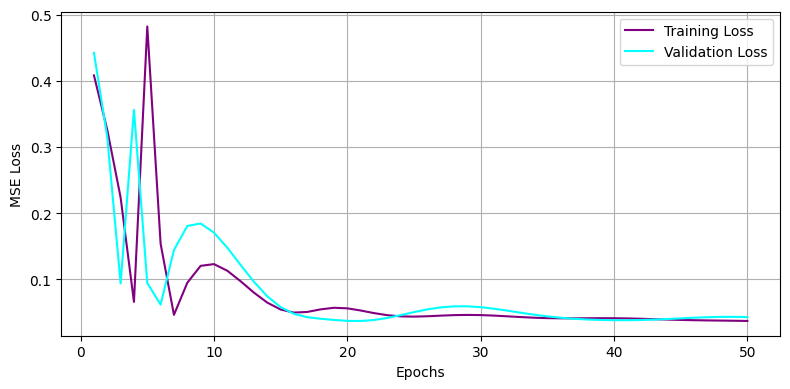

Training Physics-Informed Model: PI-LSTM
Epoch [10/50], Loss: 0.0533
Epoch [20/50], Loss: 0.0373
Epoch [30/50], Loss: 0.0232
Epoch [40/50], Loss: 0.0100
Epoch [50/50], Loss: 0.0082


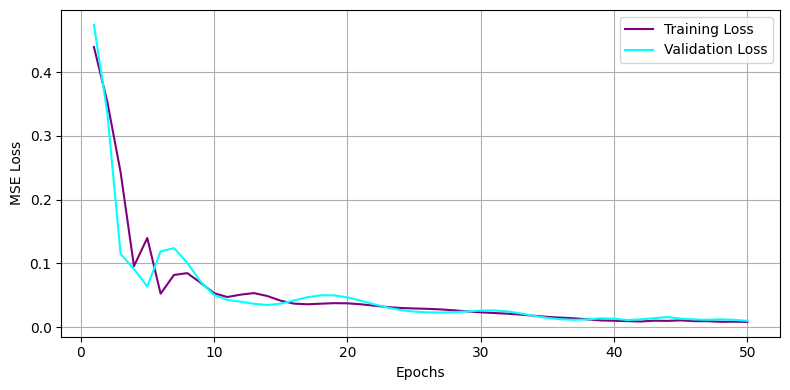

In [44]:
print("=== Starting training ===")
trained_models = train_and_tune_models(models, X_train, y_train, X_val, y_val, num_epochs=NUM_EPOCHS)

## Evaluate
Check if predicted sequences align with true values


In [45]:
colours = {
    "Ground truth": "#1589e8",
    "LSTM": "#dc267f",
    "PI-LSTM": "#ffb000",
    "Starting data": "#631ff3"
}
    # "#631ff3", "#fe5100" # - IBM colourblind palette

In [46]:
y_preds = {}
y_preds_inv = {}  # Inverse normalisation back to true temperature
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        preds = model(X_test).squeeze().numpy()
        y_preds[name] = preds # Predict on test set
        y_preds_inv[name] = np.array([scaler.inverse_transform(pred.reshape(-1, 1)) for pred in preds])

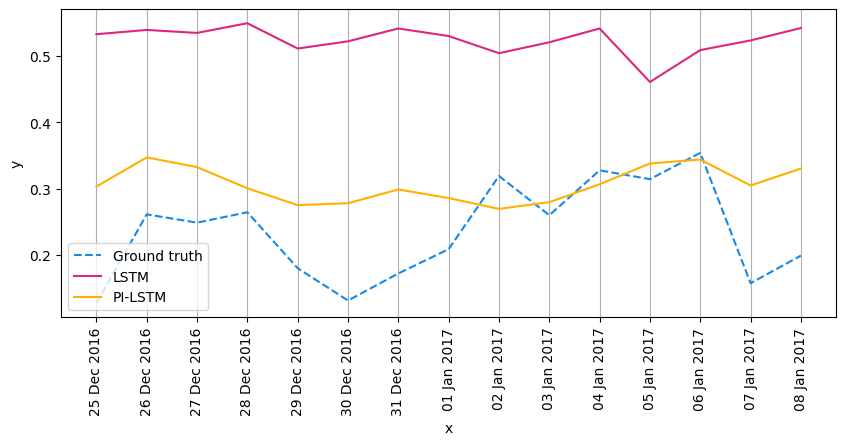

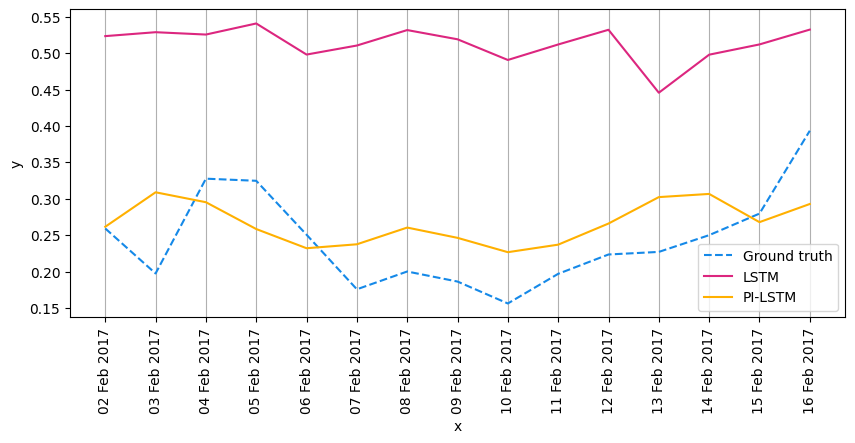

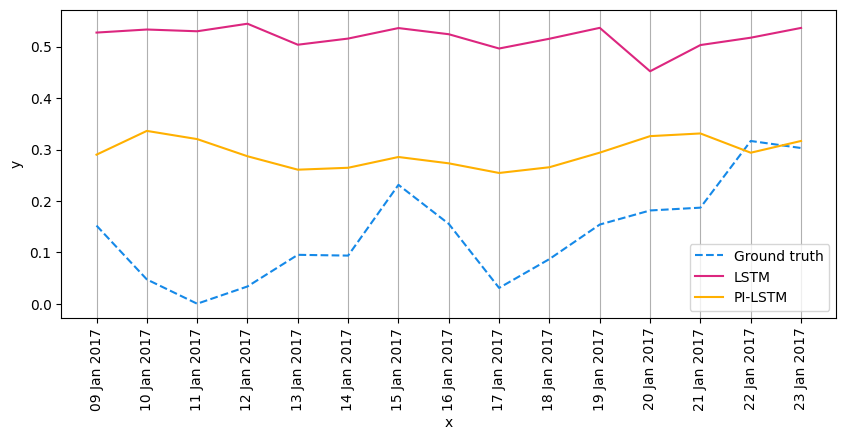

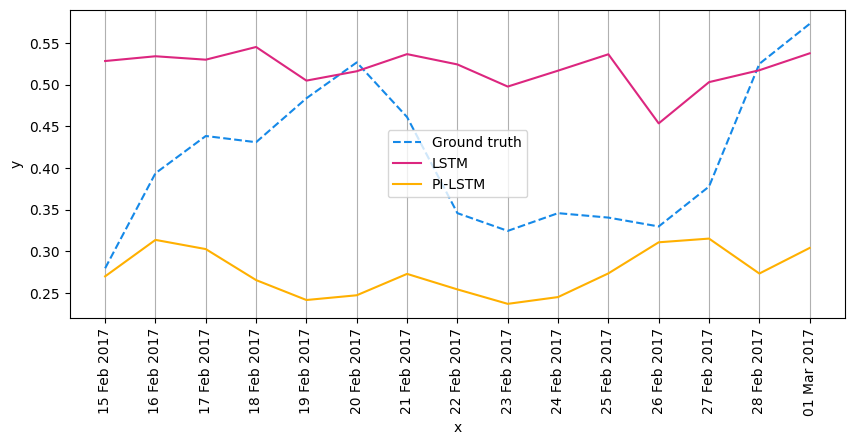

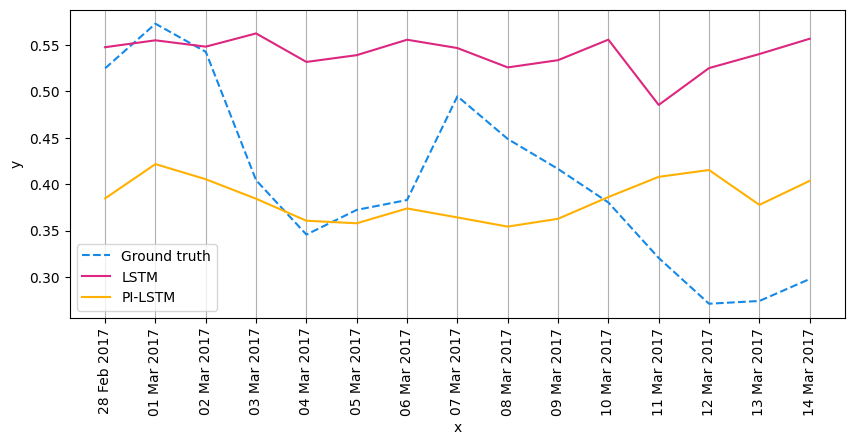

In [50]:
# Plot 5 random examples from test set!
for i in np.random.choice(range(len(y_test)-PRED_LENGTH), 5):
    # Plot actual vs predicted 
    plt.figure(figsize=(10, 4))
    times = test_df["datetimes"].values[i+SEQ_LENGTH:i+SEQ_LENGTH+PRED_LENGTH]
    plt.plot(times, y_test[i], '--', label='Ground truth', c=colours['Ground truth'])
    for name in models.keys():
        plt.plot(times, y_preds[name][i], label=name, c=colours[name])
    ax = plt.gca()
    ax.grid(visible=True, axis="x")
    ax.xaxis.set_major_locator(DayLocator(interval=1))
    ax.xaxis.set_major_formatter(DateFormatter('%d %b %Y'))
    plt.xticks(rotation=90)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

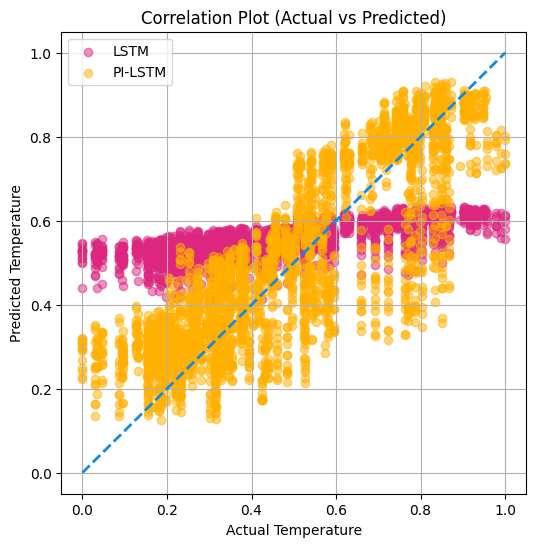

In [51]:
plt.figure(figsize=(6, 6))
for name in models.keys():
    plt.scatter(y_test.reshape(-1,1), y_preds[name].reshape(-1,1), alpha=0.5, label=name, c=colours[name])
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         '--', lw=2, c=colours['Ground truth'])
plt.title('Correlation Plot (Actual vs Predicted)')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.grid(True)
plt.legend()
plt.show()

## Autoregressive Forecasting

In [54]:
def forecast_with_model(model, start_data, forecast_length, pred_length):
    """
    Args:
        model ():
        start_data (pytorch Tensor): tensor containing the starting data sequence to forecast from
        forecast_length (int): length of data to forecast
        pred_length (int): length of returned model predictions
    """
    X_forecast = start_data
    y_forecast = []
    for i in range(int(forecast_length/pred_length)+1):
        # Predict chunk of PRED_LENGTH days enough times to cover whole test set
        # Will generate extra predictions beyond length of desired forecast
        model.eval()
        preds = model(X_forecast).squeeze().detach().numpy()
        y_forecast.append(preds)
        # Make new window
        X_old = X_forecast.squeeze().numpy()[PRED_LENGTH:]  # Convert to numpy and drop length of prediction
        X_new = np.array([np.append(X_old, preds)])  # Add prediction on end of window
        X_forecast = torch.Tensor(X_new).unsqueeze(-1)  # Convert new window to pytorch tensor
    
    # Sort out formatting of results into one long numpy array of right length (trim extra generated predictions)
    y_forecast = np.array(y_forecast).reshape(-1,1)[:forecast_length]
    return y_forecast

In [62]:
y_forecast = {}
start_data = X_test[0:1]  # Starting data: first sequence of X_test
desired_length = len(test_df)-SEQ_LENGTH
for name, model in models.items():
    print(f"Forcasting for model: {name}")
    forecast = forecast_with_model(model, start_data, desired_length, PRED_LENGTH)
    y_forecast[name] = scaler.inverse_transform(forecast)

Forcasting for model: LSTM
Forcasting for model: PI-LSTM


In [68]:
true_temps = test_df["meantemp"].values[SEQ_LENGTH:]
forecast_dates = test_df["datetimes"].values[SEQ_LENGTH:]

In [75]:
for name in models.keys():
    # Calculate RMSE
    rmse = np.sqrt(np.mean((y_forecast[name].squeeze() - true_temps) ** 2))

    # Calculate Pearson correlation
    correlation, _ = pearsonr(y_forecast[name].squeeze(), true_temps)

    print(f"Metrics for model - {name}:")
    print(f"RMSE:\t\t{rmse}")
    print(f"P-CORR:\t\t{correlation}")

Metrics for model - LSTM:
RMSE:		6.147082145900449
P-CORR:		0.3384543261195845
Metrics for model - PI-LSTM:
RMSE:		8.549750193913436
P-CORR:		0.25373685404453994


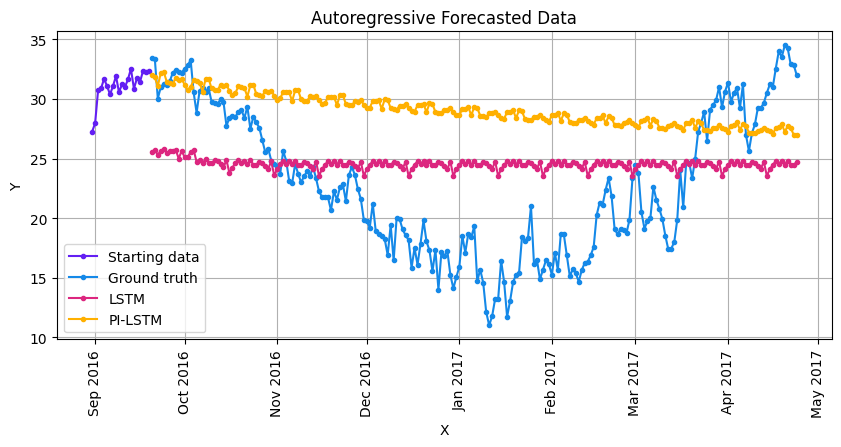

In [69]:
# Plot actual vs predicted
plt.figure(figsize=(10, 4))

# Starting data: first sequence of X_test
start_data_inv = scaler.inverse_transform(start_data.reshape(-1,1)).squeeze()
plt.plot(test_df["datetimes"].values[:SEQ_LENGTH], start_data_inv, marker='.', label='Starting data', c=colours['Starting data'])

# Ground truth: test data across region predicted for
plt.plot(forecast_dates, true_temps, label='Ground truth', marker='.', c=colours['Ground truth'])

# Predictions
for name in models.keys():
    plt.plot(forecast_dates, y_forecast[name], label=name, marker='.', c=colours[name])
plt.title("Autoregressive Forecasted Data")
ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator(interval=1))
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
plt.xticks(rotation=90)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

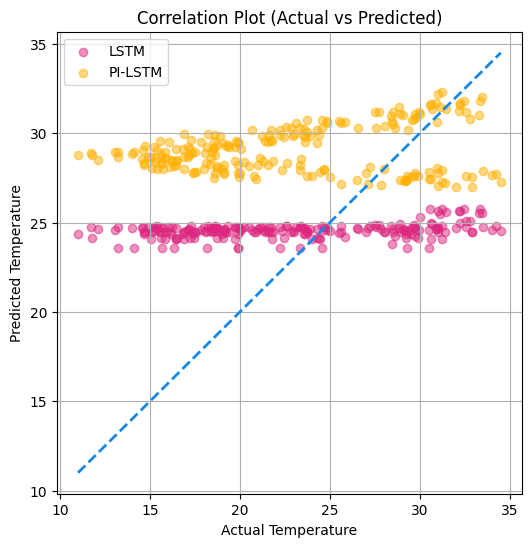

In [70]:
plt.figure(figsize=(6, 6))
for name in models.keys():
    plt.scatter(true_temps, y_forecast[name], alpha=0.5, label=name, c=colours[name])
plt.plot([true_temps.min(), true_temps.max()], 
         [true_temps.min(), true_temps.max()], 
         '--', lw=2, c=colours['Ground truth'])
plt.title('Correlation Plot (Actual vs Predicted)')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.grid(True)
plt.legend()
plt.show()
